# Task 1.1: Detect Missing Values

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel('Practice_Dataset.xlsx')

# How many missing values per column?
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'Dataset shape: {df.shape}')

# What percentage of each column is missing?
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print('\nMissing percentage per column:')
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

badge_number           0
name                   0
position               0
work_date              0
in_time               35
out_time              35
punch_count            0
status                 0
hours_worked          35
department             6
monthly_salary        13
satisfaction_score    12
is_absent              0
dtype: int64

Total missing: 136
Dataset shape: (360, 13)

Missing percentage per column:
in_time               9.72
out_time              9.72
hours_worked          9.72
monthly_salary        3.61
satisfaction_score    3.33
department            1.67
dtype: float64


# Task 1.2: Visualize Missing Data

In [3]:
!pip install missingno

  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


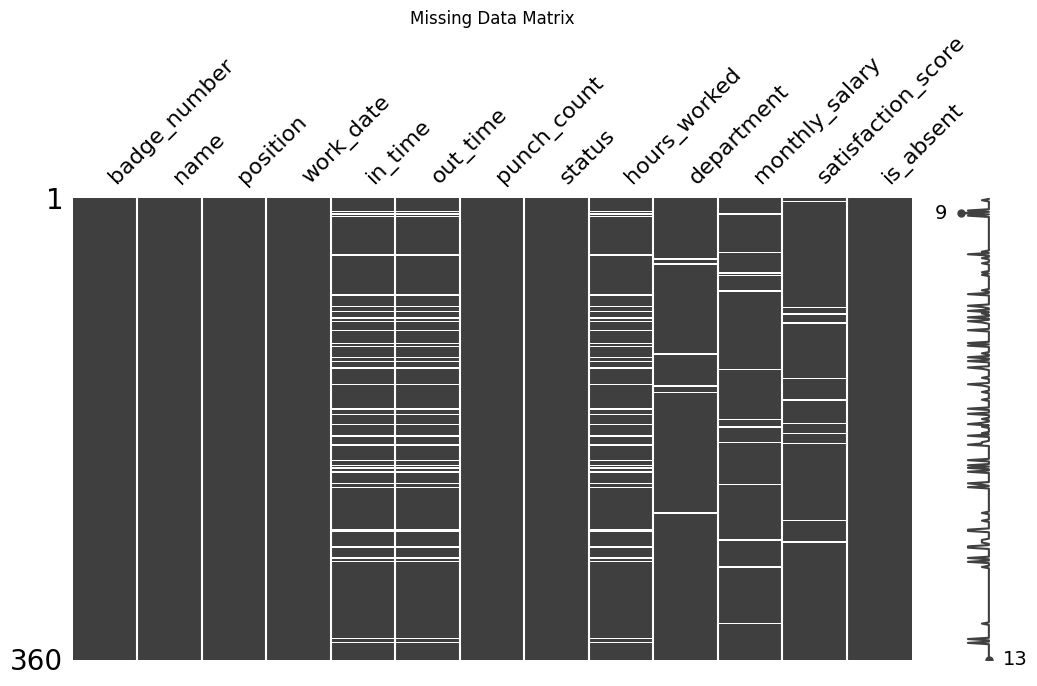

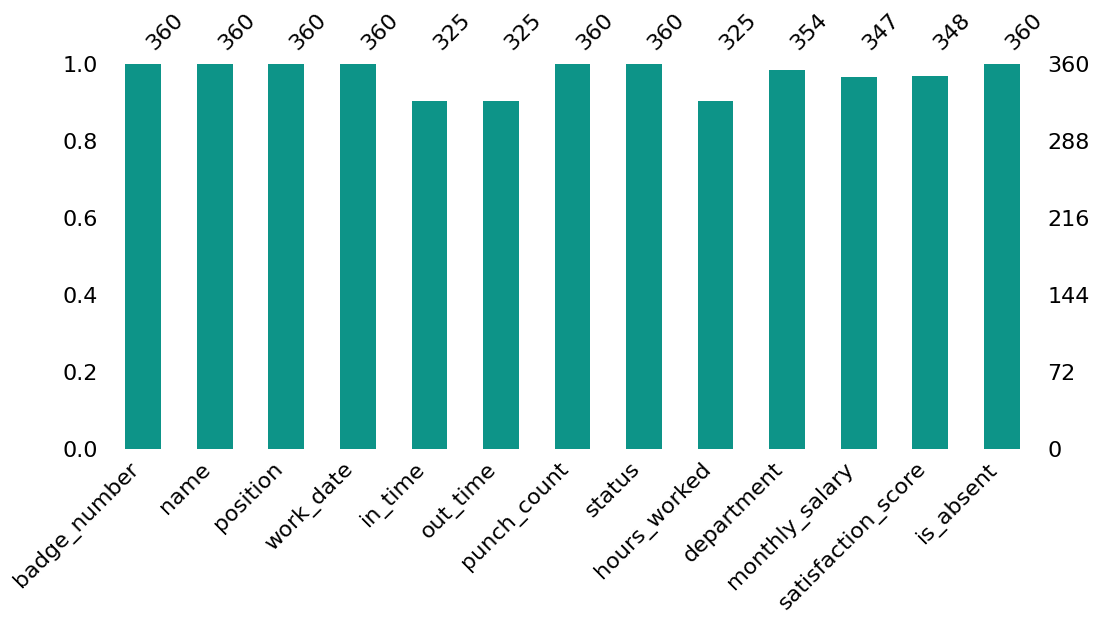

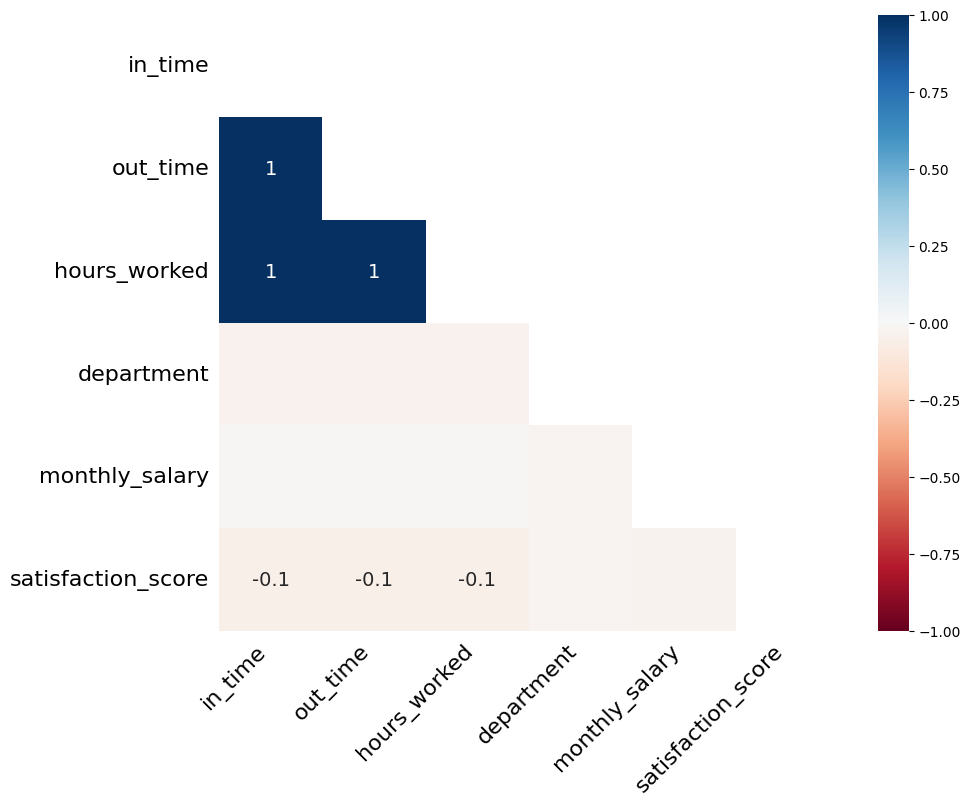

In [5]:
import missingno as msno
import matplotlib.pyplot as plt

# Matrix view — white lines = missing values
msno.matrix(df, figsize=(12, 6))
plt.title('Missing Data Matrix')
plt.savefig('missing_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart — shows completeness per column
msno.bar(df, figsize=(12, 5), color='#0D9488')
plt.savefig('missing_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap — shows correlation between missing values
msno.heatmap(df, figsize=(10, 8))
plt.savefig('missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Task 1.3: Strategy 1 — Drop Missing Data

In [6]:
df_copy = df.copy()  # Always work on a copy!

# Drop rows where ANY value is missing
df_dropped_any = df_copy.dropna()
print(f'Before: {len(df_copy)} rows -> After dropna(): {len(df_dropped_any)} rows')

# Drop rows where a SPECIFIC column is missing
df_dropped_col = df_copy.dropna(subset=['status'])
print(f'After dropping missing status: {len(df_dropped_col)} rows')

# Drop columns that are mostly empty (> 50% missing)
threshold = len(df_copy) * 0.5
df_dropped_cols = df_copy.dropna(axis=1, thresh=int(threshold))
print(f'Columns before: {df_copy.shape[1]} -> After: {df_dropped_cols.shape[1]}')

Before: 360 rows -> After dropna(): 295 rows
After dropping missing status: 360 rows
Columns before: 13 -> After: 13


# Task 1.4: Strategy 2 — Fill Missing Data

In [7]:
df_fill = df.copy()

# Fill numeric columns with the MEDIAN (robust to outliers)
numeric_cols = df_fill.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_fill[col].isnull().sum() > 0:
        median_val = df_fill[col].median()
        df_fill[col] = df_fill[col].fillna(median_val)  # fix: avoid chained assignment
        print(f'Filled {col} with median: {median_val}')

# Fill categorical columns with the MODE (most frequent value)
cat_cols = df_fill.select_dtypes(include='object').columns
for col in cat_cols:
    if df_fill[col].isnull().sum() > 0:
        mode_val = df_fill[col].mode()[0]
        df_fill[col] = df_fill[col].fillna(mode_val)  # fix: avoid chained assignment
        print(f'Filled {col} with mode: {mode_val}')

# Verify: no more missing values
print(f'\nRemaining missing values: {df_fill.isnull().sum().sum()}')

Filled hours_worked with median: 9.1
Filled monthly_salary with median: 8125.0
Filled satisfaction_score with median: 4.0
Filled in_time with mode: 06:19
Filled out_time with mode: 16:38
Filled department with mode: Operations

Remaining missing values: 0


# Task 1.5: Document Your Decisions

In [9]:
cleaning_log = []
cleaning_log.append({'column': 'in_time', 'issue': '35 missing values (9.72%)',
    'action': "Filled with mode ('06:19')", 'reason': 'Categorical/time field, mode = most common shift start'})
cleaning_log.append({'column': 'out_time', 'issue': '35 missing values (9.72%)',
    'action': "Filled with mode ('16:38')", 'reason': 'Categorical/time field, mode = most common shift end'})
cleaning_log.append({'column': 'hours_worked', 'issue': '35 missing values (9.72%)',
    'action': 'Filled with median (9.1)', 'reason': 'Numeric, median is robust to outliers'})
cleaning_log.append({'column': 'monthly_salary', 'issue': '13 missing values (3.61%)',
    'action': 'Filled with median (8125.0)', 'reason': 'Numeric, median avoids skew from high earners'})
cleaning_log.append({'column': 'satisfaction_score', 'issue': '12 missing values (3.33%)',
    'action': 'Filled with median (4.0)', 'reason': 'Numeric ordinal score, median is a safe default'})
cleaning_log.append({'column': 'department', 'issue': '6 missing values (1.67%)',
    'action': "Filled with mode ('Operations')", 'reason': 'Categorical, mode = most frequent department'})

log_df = pd.DataFrame(cleaning_log)
print(log_df)
log_df.to_csv('cleaning_log.csv', index=False)

               column                      issue  \
0             in_time  35 missing values (9.72%)   
1            out_time  35 missing values (9.72%)   
2        hours_worked  35 missing values (9.72%)   
3      monthly_salary  13 missing values (3.61%)   
4  satisfaction_score  12 missing values (3.33%)   
5          department   6 missing values (1.67%)   

                            action  \
0       Filled with mode ('06:19')   
1       Filled with mode ('16:38')   
2         Filled with median (9.1)   
3      Filled with median (8125.0)   
4         Filled with median (4.0)   
5  Filled with mode ('Operations')   

                                              reason  
0  Categorical/time field, mode = most common shi...  
1  Categorical/time field, mode = most common shi...  
2              Numeric, median is robust to outliers  
3      Numeric, median avoids skew from high earners  
4    Numeric ordinal score, median is a safe default  
5       Categorical, mode = most frequ